In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import  Path
%pip install japanize-matplotlib
import japanize_matplotlib 

Note: you may need to restart the kernel to use updated packages.


In [3]:
input_dir=Path("/kaggle/input/cmi-detect-behavior-with-sensor-data/")
print(list(input_dir.iterdir()))

df_tr=pd.read_csv(input_dir/"train.csv")
df_demo=pd.read_csv(input_dir/"train_demographics.csv")
print(f"train.csv shape: {df_tr.shape}")
print(f"train_demographics.csv shape: {df_demo.shape}")
df_tr.head()

[PosixPath('/kaggle/input/cmi-detect-behavior-with-sensor-data/kaggle_evaluation'), PosixPath('/kaggle/input/cmi-detect-behavior-with-sensor-data/cmi-detect-behavior-with-sensor-data.zip'), PosixPath('/kaggle/input/cmi-detect-behavior-with-sensor-data/test.csv'), PosixPath('/kaggle/input/cmi-detect-behavior-with-sensor-data/train_demographics.csv'), PosixPath('/kaggle/input/cmi-detect-behavior-with-sensor-data/train.csv'), PosixPath('/kaggle/input/cmi-detect-behavior-with-sensor-data/test_demographics.csv')]
train.csv shape: (574945, 341)
train_demographics.csv shape: (81, 8)


,row_id,sequence_type,sequence_id,sequence_counter,subject,orientation,behavior,phase,gesture,acc_x,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
0,SEQ_000007_000000,Target,SEQ_000007,0,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.683594,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,SEQ_000007_000001,Target,SEQ_000007,1,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.949219,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,SEQ_000007_000002,Target,SEQ_000007,2,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,5.722656,...,-1.0,-1.0,112.0,119.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,SEQ_000007_000003,Target,SEQ_000007,3,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.601562,...,-1.0,-1.0,101.0,111.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,SEQ_000007_000004,Target,SEQ_000007,4,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,5.566406,...,-1.0,-1.0,101.0,109.0,125.0,-1.0,-1.0,-1.0,-1.0,-1.0


In [5]:
from experiments.exp006_I.src.preprocess import Preprocessor
preprocessor = Preprocessor()

df = preprocessor.fit_transform(df_tr)

利用可能なカラム: ['linear_acc_x', 'linear_acc_y', 'linear_acc_z', 'rot_x', 'rot_y', 'rot_z', 'rot_w']


NameError: name 'Patch' is not defined

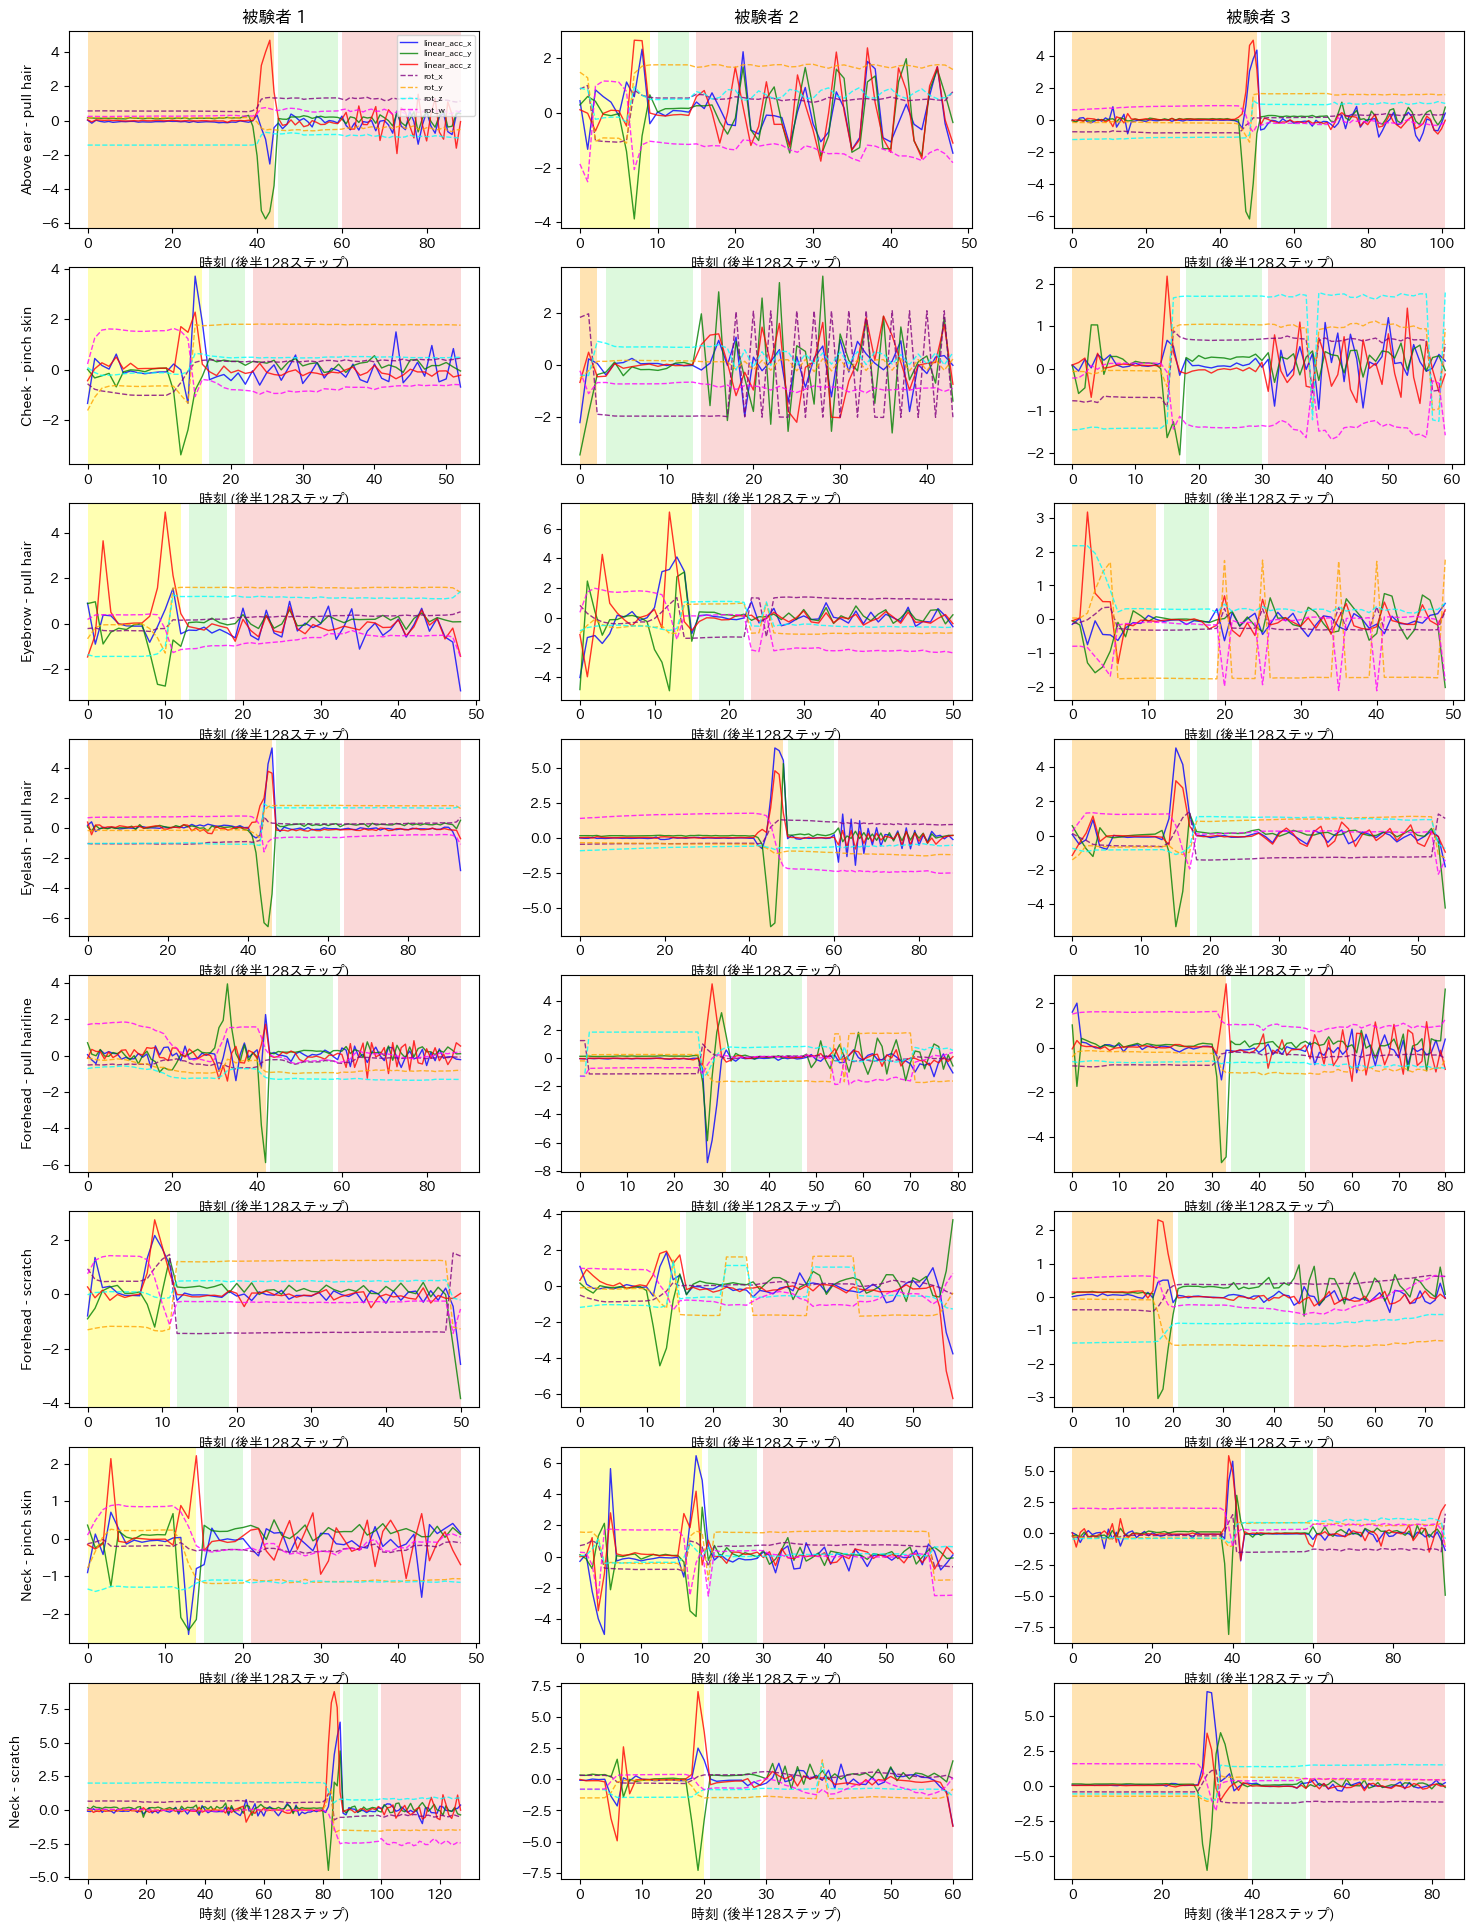

In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# 9つのターゲットラベル
gestures = TARGET_GESTURES

# linear_accとrotのカラム
linear_acc_cols = ['linear_acc_x', 'linear_acc_y', 'linear_acc_z'] if 'linear_acc_x' in df.columns else ['acc_x', 'acc_y', 'acc_z']
rot_cols = ['rot_x', 'rot_y', 'rot_z', 'rot_w'] if 'rot_x' in df.columns else ['roll', 'pitch', 'yaw']

# 実際に存在するカラムを確認
plot_cols = [c for c in linear_acc_cols + rot_cols if c in df.columns]
print(f"利用可能なカラム: {plot_cols}")

# behaviorの色マッピング
behavior_colors = {
    'Relaxes and moves hand to target location': 'yellow',
    'Moves hand to target location': 'orange',
    'Hand at target location': 'lightgreen',
    'Performs gesture': 'lightcoral',
}

# 後半128ステップを使用
TAIL_LENGTH = 128

# 9ジェスチャー × 3被験者 のFigureを作成
n_gestures = len(gestures)
n_subjects_per_gesture = 3

fig, axes = plt.subplots(n_gestures, n_subjects_per_gesture, figsize=(18, 3 * n_gestures))

for gesture_idx, gesture in enumerate(gestures):
    # このジェスチャーに対応するデータを取得
    gesture_data = df[df['gesture'] == gesture]
    
    # ユニークな被験者を取得し、最大3人サンプリング
    subjects = gesture_data['subject'].unique()
    sampled_subjects = np.random.choice(subjects, size=min(n_subjects_per_gesture, len(subjects)), replace=False)
    
    for subj_idx, subject in enumerate(sampled_subjects):
        ax = axes[gesture_idx, subj_idx]
        
        # この被験者のこのジェスチャーからシーケンスを1つ選択
        subj_data = gesture_data[gesture_data['subject'] == subject]
        seq_ids = subj_data['sequence_id'].unique()
        seq_id = np.random.choice(seq_ids)
        
        # シーケンスデータを取得し、後半128ステップのみ
        sample = subj_data[subj_data['sequence_id'] == seq_id].sort_values('sequence_counter')
        sample = sample.tail(TAIL_LENGTH)
        
        if len(sample) == 0:
            continue
        
        t = np.arange(len(sample))
        
        # behaviorの背景色を塗る
        behaviors = sample['behavior'].values
        i = 0
        while i < len(behaviors):
            current_behavior = behaviors[i]
            start_idx = i
            while i < len(behaviors) and behaviors[i] == current_behavior:
                i += 1
            end_idx = i - 1
            color = behavior_colors.get(current_behavior, 'gray')
            ax.axvspan(t[start_idx], t[end_idx], alpha=0.3, color=color, linewidth=0)
        
        # linear_accをプロット (実線)
        colors_acc = ['blue', 'green', 'red']
        for col_idx, col in enumerate(linear_acc_cols):
            if col in sample.columns:
                ax.plot(t, sample[col].values, color=colors_acc[col_idx], linewidth=1, alpha=0.8, 
                       label=col)
        
        # rotをプロット (点線)
        colors_rot = ['purple', 'orange', 'cyan', 'magenta']
        for col_idx, col in enumerate(rot_cols):
            if col in sample.columns:
                ax.plot(t, sample[col].values, color=colors_rot[col_idx], linewidth=1, alpha=0.8, 
                       linestyle='--', label=col)
        
        ax.set_xlabel('時刻 (後半128ステップ)')
        
        # 左端のみにY軸ラベル
        if subj_idx == 0:
            ax.set_ylabel(gesture[:25] + '...' if len(gesture) > 25 else gesture)
        
        # 上端のみにタイトル
        if gesture_idx == 0:
            ax.set_title(f'被験者 {subj_idx + 1}')
        
        # 最初のサブプロットにのみ凡例
        if gesture_idx == 0 and subj_idx == 0:
            ax.legend(loc='upper right', fontsize=6)

# 凡例用のダミープロット
legend_elements = [
    Patch(facecolor='yellow', alpha=0.4, label='Relaxes and moves'),
    Patch(facecolor='orange', alpha=0.4, label='Moves to target'),
    Patch(facecolor='lightgreen', alpha=0.4, label='Hand at target'),
    Patch(facecolor='lightcoral', alpha=0.4, label='Performs gesture'),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=4, fontsize=9, bbox_to_anchor=(0.5, 1.02))

plt.suptitle('9つのターゲットラベル × 3被験者: linear_acc & rot (後半128ステップ)\n背景色: behavior遷移', 
             fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

In [10]:
df_tr.groupby("sequence_id").max().describe()

,sequence_counter,acc_x,acc_y,acc_z,rot_w,rot_x,rot_y,rot_z,thm_1,thm_2,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
count,8151.000000,8151.000000,8151.000000,8151.000000,8101.000000,8101.000000,8101.000000,8101.000000,8047.000000,8035.000000,...,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000,7717.000000
mean,69.536744,8.574135,6.944849,8.114600,0.596042,0.334815,0.416345,0.246991,29.341450,29.725809,...,137.449009,129.325774,179.228327,174.203447,167.528573,159.106000,150.550603,142.536737,136.153557,132.983284
std,35.389879,4.372180,3.783337,4.903285,0.197422,0.394216,0.409587,0.478518,2.871653,2.634421,...,87.789841,87.119336,67.977257,73.842278,79.290767,83.085511,84.602009,86.263894,85.632542,85.907832
min,28.000000,-9.031250,-6.863281,-8.984375,0.026123,-0.908386,-0.898865,-0.856689,0.668110,23.094677,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,50.000000,6.724609,4.687500,6.109375,0.450806,0.035645,0.058472,-0.124634,27.960691,27.611207,...,64.000000,55.000000,143.000000,137.000000,123.000000,102.000000,88.000000,74.000000,68.000000,63.000000
50%,58.000000,9.398438,7.792969,9.355469,0.571228,0.363220,0.541199,0.379761,29.724812,30.142834,...,158.000000,143.000000,200.000000,198.000000,195.000000,188.000000,174.000000,163.000000,152.000000,146.000000
75%,77.000000,11.150391,9.535156,11.226562,0.769348,0.667480,0.790466,0.619873,31.064990,31.893731,...,217.000000,208.000000,235.000000,234.000000,233.000000,231.000000,225.000000,221.000000,214.000000,210.000000
max,699.000000,46.328125,27.183594,30.078125,0.999390,0.999817,0.999451,0.999878,38.457664,37.578339,...,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000,249.000000
